# Анализ прямой задачи

В формулы подставляется и варьруется величина волнового числа $k = \omega\sqrt{\mu_0\mu\epsilon_0\epsilon}$ и толщины слоя $h$.

Известно, что $$c = \frac{1}{\sqrt{\mu_0\epsilon_0}}$$, тогда получаем, что $$k = \frac{\omega}{c}\sqrt{\mu\epsilon}$$, где $$\omega - \text{круговая частота}$$ $$c - \text{скорость света}$$ $$\mu,\epsilon - \text{относительная магнитная и диэлектрическая проницаемость среды}$$

Тогда $k_0 = \frac{\omega}{c} = \frac{2\pi}{\lambda_0}$ - волновое чсило вакуума, а $n = \sqrt{\mu\epsilon}$ - показатель преломления.

Для исследования некорректности обратной задачи зафиксируем длину волны $\lambda_0$ в коде и будем вычислять остальные величины как: $$k_0 = \frac{2\pi}{\lambda_0}$$ $$\tilde{h} = k_0h$$ $$\tilde{k}=\frac{k}{k_0} = n_i$$

То есть $k = n_ik_0$, а $\tilde{h}=k_0h$ - безразмерные величины

## Import

In [231]:
import numpy as np
import matplotlib.pyplot as plt
from physics import *

## Forward graphs

In [232]:
theta0 = np.deg2rad(30)

lambda0 = 2 * np.pi # Длина волны в метрах
k0 = 2 * np.pi / lambda0

n1 = 1.0 # воздух
n2 = 1.0 # подложка

h_base = 0.5 # толщина слоя в метрах
theta0 = np.deg2rad(30) # Угол в радианах

In [233]:
n_vals = np.linspace(0.0, 12.0, 10000) # Показатели преломления материала

r_vals = [r_total(np.array([n1, n, n2]) * k0, h_base, theta0) for n in n_vals] # Посчитанные значения коэфициентов отражения

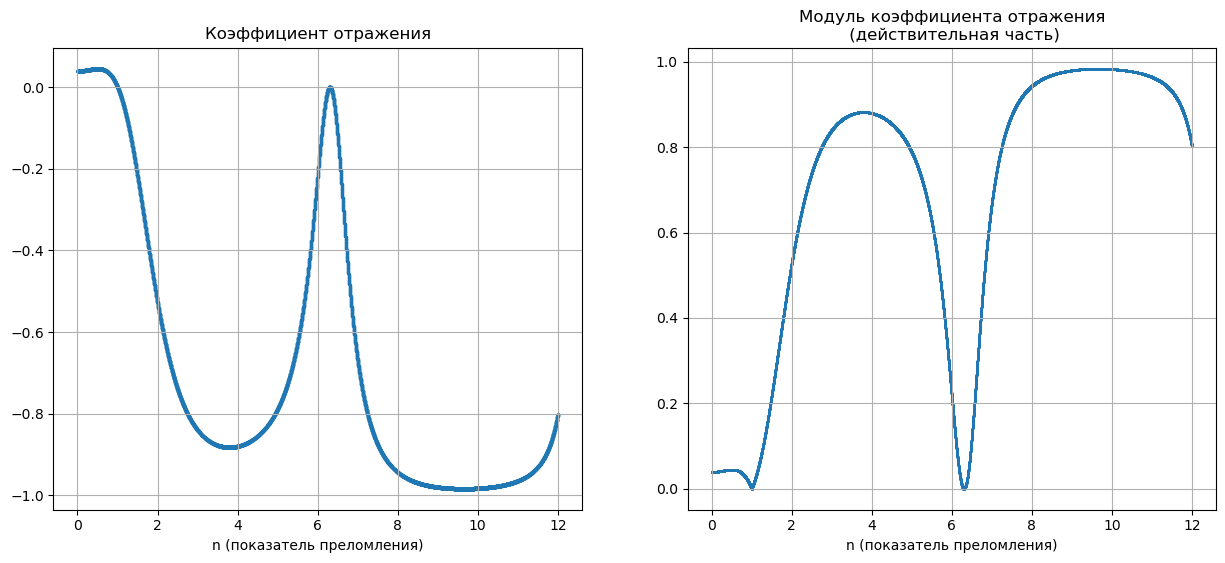

In [234]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(n_vals, np.real(r_vals), s=2)
ax1.set_title('Коэффициент отражения')
ax1.set_xlabel('n (показатель преломления)')
ax1.grid()

ax2.scatter(n_vals, np.abs(np.real(r_vals)), s=1)
ax2.set_title('Модуль коэффициента отражения\n (действительная часть)')
ax2.set_xlabel('n (показатель преломления)')
ax2.grid()

На графиках наблюдаются быстрые осцилляции коэффициента отражения как функции показателя преломления. Это означает, что небольшие изменения параметров среды могут приводить к существенным изменениям отраженного сигнала. Следовательно, при наличии шума в измерениях восстановление параметров может оказаться неустойчивым.

In [236]:
print("Максимум |r| =", np.max(np.abs(r_vals)))

Максимум |r| = 0.9839617700984582


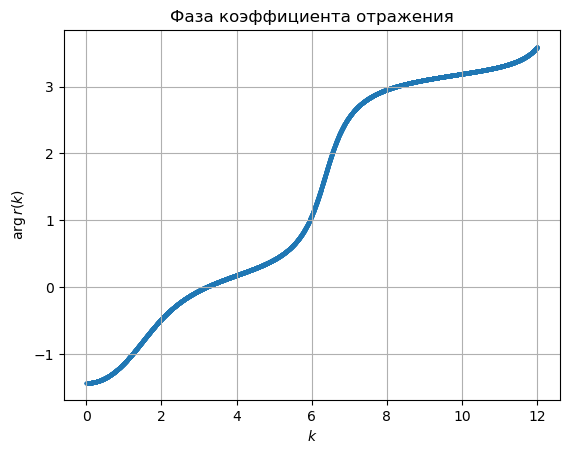

In [235]:
plt.figure()
plt.scatter(n_vals, np.unwrap(np.angle(r_vals), period=np.pi), s=3)
plt.xlabel(r"$k$")
plt.ylabel(r"$\arg r(k)$")
plt.title("Фаза коэффициента отражения")
plt.grid()
plt.show()

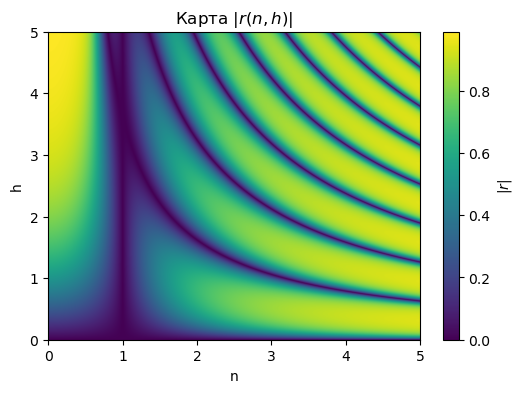

In [237]:
h_vals = np.linspace(0, 5, 1500)
n_vals = np.linspace(0, 5, 1500)

R = r_map(n_vals, h_vals, n1, n2, k0, theta0)

plt.figure(figsize=(6, 4))
plt.imshow(
    np.abs(R),
    origin="lower",
    extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar(label=r"$|r|$")
plt.xlabel("n")
plt.ylabel("h")
plt.title(r"Карта $|r(n,h)|$")
plt.show()

На этом графике наличие вытянутых долин может говорить о сильной корреляции между $n,h$, то есть изменение одного параметра может компенсироваться изменением второго, при этом давай близкие значения $r$.

Появление семейства долин связано с периодической зависимостью коэффициента отражения от фазового набега. Линии постоянной фазы приблизительно соответствуют условиям фазовый набег=const.

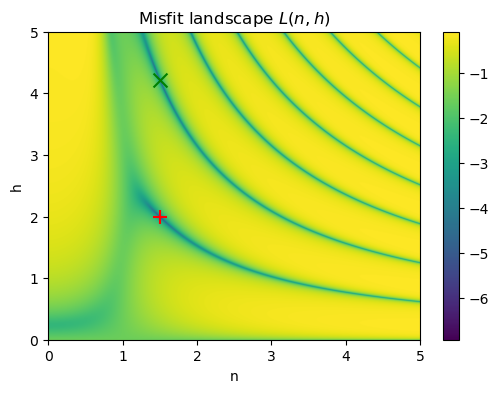

In [ ]:
n_true = 1.5
h_true = 2.0

r_true = r_total(
    np.array([n1, n_true, n2]) * k0,
    h_true,
    theta0
)

R = r_map(n_vals, h_vals, n1, n2, k0, theta0)

loss = np.abs(R - r_true) ** 2

plt.figure(figsize=(6, 4))
plt.imshow(
    np.log10(loss),
    origin="lower",
    extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar()
plt.xlabel("n")
plt.ylabel("h")
plt.title(r"Misfit landscape $L(n,h)$")
plt.scatter(
    n_true,
    h_true,
    c='red',
    s=100,
    marker='+'
)
idx = np.unravel_index(np.argmin(loss), loss.shape)
plt.scatter(
    n_vals[idx[1]],
    h_vals[idx[0]],
    c='green',
    s=100,
    marker='x'
)
plt.show()

На карте невязки наблюдаются вытянутые долины локальных минимумов. Это означает, что одному и тому же измеренному коэффициенту отражения могут соответствовать различные пары параметров (n,h). Следовательно, обратная задача неоднозначна при использовании данных только для одного угла падения.

Recovered:
Area =  6
min loss = 8.674519801747128e-08
n = 3.3288859239492994
h = 1.0973982655103403
Recovered:
Area =  378
min loss = 3.045223234584788e-05
n = 3.3755837224816543
h = 2.0146764509673116
Recovered:
Area =  441
min loss = 8.36188556051359e-05
n = 3.422281521014009
h = 1.9846564376250833
Recovered:
Area =  734
min loss = 0.00023676619086596048
n = 3.4823215476984655
h = 1.9479653102068044
Recovered:
Area =  536
min loss = 0.00026790481552309205
n = 3.4823215476984655
h = 1.9479653102068044


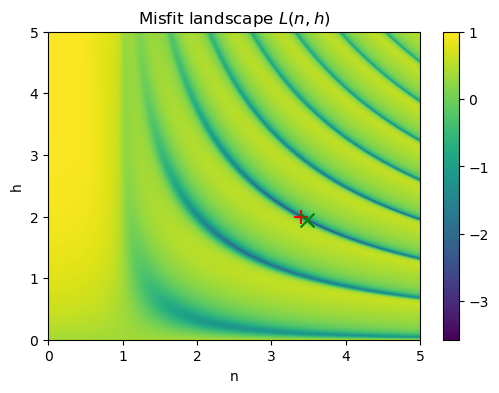

In [249]:
n_true = 3.4
h_true = 2.0

loss = np.zeros_like(R, dtype=float)

mins = []
areas = []

for theta in [15, 30, 45, 60, 75]:
    theta = np.deg2rad(theta)

    R_theta = r_map(n_vals, h_vals, n1, n2, k0, theta)

    r_true = r_total(
        np.array([n1, n_true, n2]) * k0,
        h_true,
        theta
    )

    sigma = 1e-2
    r_true_noisy = (
        r_true
        + sigma*np.random.randn()
        + 1j*sigma*np.random.randn()
    )

    # loss += np.abs(R_theta - r_true)**2
    loss += np.abs(R_theta - r_true_noisy)**2
    idx = np.unravel_index(np.argmin(loss), loss.shape)

    log_loss = np.log10(loss)

    level = log_loss.min() + 1

    area = np.sum(log_loss < level)

    areas.append(area)
    mins.append(loss.min())

    idx = np.unravel_index(np.argmin(loss), loss.shape)

    print("Recovered:")
    print("Area = ", area)
    print("min loss =", loss[idx])
    print("n =", n_vals[idx[1]])
    print("h =", h_vals[idx[0]])


plt.figure(figsize=(6, 4))
plt.imshow(
    np.log10(loss),
    origin="lower",
    extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar()
plt.xlabel("n")
plt.ylabel("h")
plt.title(r"Misfit landscape $L(n,h)$")
plt.scatter(
    n_true,
    h_true,
    c='red',
    s=100,
    marker='+'
)
idx = np.unravel_index(np.argmin(loss), loss.shape)
plt.scatter(
    n_vals[idx[1]],
    h_vals[idx[0]],
    c='green',
    s=100,
    marker='x'
)
plt.show()

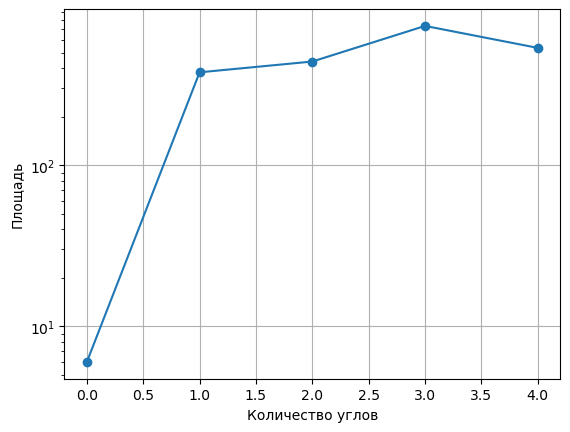

In [250]:
plt.semilogy(areas, marker='o')
plt.xlabel("Количество углов")
plt.ylabel("Площадь")
plt.grid()

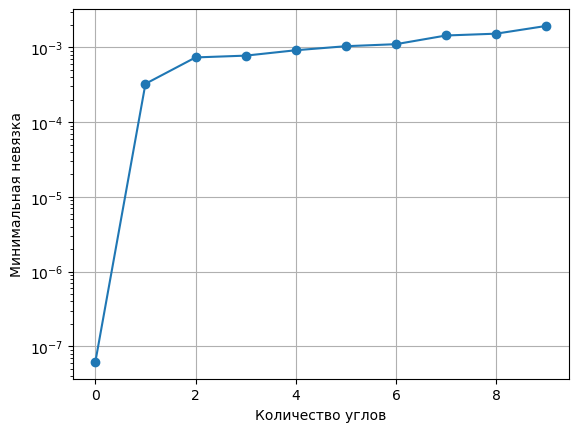

In [244]:
plt.semilogy(mins, marker='o')
plt.xlabel("Количество углов")
plt.ylabel("Минимальная невязка")
plt.grid()

## Tichonov